In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
import pandas as pd
import seaborn as sns
from scipy import signal
#from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import HuberRegressor, TheilSenRegressor
import ipywidgets as widgets
from src.analisi.tools import *

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
# selettore cartella
print(base_img_folder)
folder_selector = widgets.Dropdown( 
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

data/raw


Dropdown(description='Sessione:', options=('percolazione', 'lampadina_test_final', 'lampadina3_test', 'lampadi…

In [4]:
bilancia_timestamps, bilancia_thicknesses, bilancia_rates = load_bilancia_data(os.path.join(base_img_folder, folder_selector.value, "data", 'points.txt'))
bilancia_timestamps = np.array(bilancia_timestamps)
bilancia_trel = bilancia_timestamps - bilancia_timestamps[0]
bilancia_thicknesses = np.array(bilancia_thicknesses)
print(bilancia_timestamps)
print(bilancia_timestamps.shape)

[1.77748066e+09 1.77748066e+09 1.77748066e+09 ... 1.77748085e+09
 1.77748085e+09 1.77748085e+09]
(4480,)


In [5]:
#raccolgiamo le immagini per calcolare le intensità medie 

images, image_timestamps = load_images_from_folder(os.path.join(base_img_folder, folder_selector.value, 'images'))
images, image_timestamps = sort_images_and_timestamps(images, image_timestamps)

image_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in image_timestamps]
image_seconds = np.array(image_seconds)

image_trel = image_seconds - image_seconds[0]

In [6]:
print(image_seconds.shape)
print(image_seconds)

(659,)
[1.77748068e+09 1.77748068e+09 1.77748068e+09 1.77748068e+09
 1.77748068e+09 1.77748068e+09 1.77748068e+09 1.77748068e+09
 1.77748068e+09 1.77748069e+09 1.77748069e+09 1.77748069e+09
 1.77748069e+09 1.77748069e+09 1.77748069e+09 1.77748069e+09
 1.77748069e+09 1.77748069e+09 1.77748070e+09 1.77748070e+09
 1.77748070e+09 1.77748070e+09 1.77748070e+09 1.77748070e+09
 1.77748070e+09 1.77748070e+09 1.77748070e+09 1.77748070e+09
 1.77748070e+09 1.77748071e+09 1.77748071e+09 1.77748071e+09
 1.77748071e+09 1.77748071e+09 1.77748071e+09 1.77748071e+09
 1.77748071e+09 1.77748071e+09 1.77748072e+09 1.77748072e+09
 1.77748072e+09 1.77748072e+09 1.77748072e+09 1.77748072e+09
 1.77748072e+09 1.77748072e+09 1.77748072e+09 1.77748072e+09
 1.77748072e+09 1.77748073e+09 1.77748073e+09 1.77748073e+09
 1.77748073e+09 1.77748073e+09 1.77748073e+09 1.77748073e+09
 1.77748073e+09 1.77748073e+09 1.77748074e+09 1.77748074e+09
 1.77748074e+09 1.77748074e+09 1.77748074e+09 1.77748074e+09
 1.77748074e+09 1

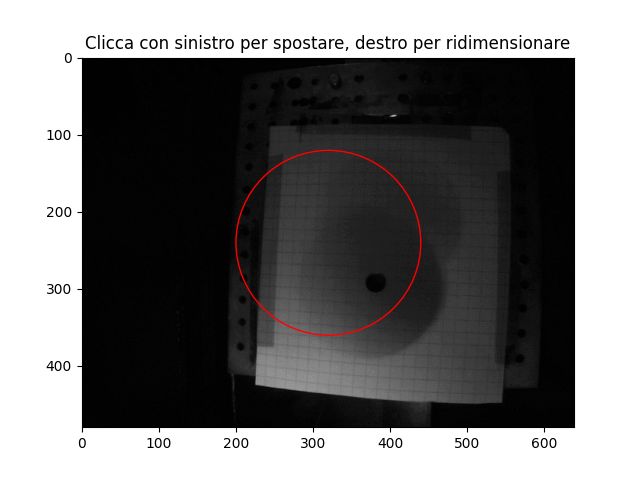

In [7]:
roi_select = RoiSelectorWidget(images[-1])

In [8]:
roi_center, roi_radius = roi_select.roi

In [9]:
def build_roi(im0, center_x, center_y, radius):
    
    h, w = im0.shape[:2]
    Y, X = np.ogrid[:h, :w]
    
    dist_from_center = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
    
    mask = dist_from_center <= radius
    
    return mask

def extract_roi_from_images(images, mask):
    return [image * mask for image in images]

def compute_mean(images, roi_mask):
    return [np.mean(image[roi_mask > 0]) for image in images]

def compute_diff_imgs(images, reference_image):
    return [reference_image - image for image in images]

In [10]:
reference_image = np.mean(images[:10], axis=0) if images else None
roi_mask = build_roi(reference_image, roi_center[0], roi_center[1], roi_radius)
roi_images = extract_roi_from_images(images, roi_mask)
reference_image_roi = extract_roi_from_images([reference_image], roi_mask)[0]
difference_images = compute_diff_imgs(roi_images, reference_image_roi)
mean_intensities = np.array(compute_mean(difference_images, roi_mask))

In [11]:
print(mean_intensities.shape)
print(image_trel.shape)

(659,)
(659,)


<function matplotlib.pyplot.show(block=None)>

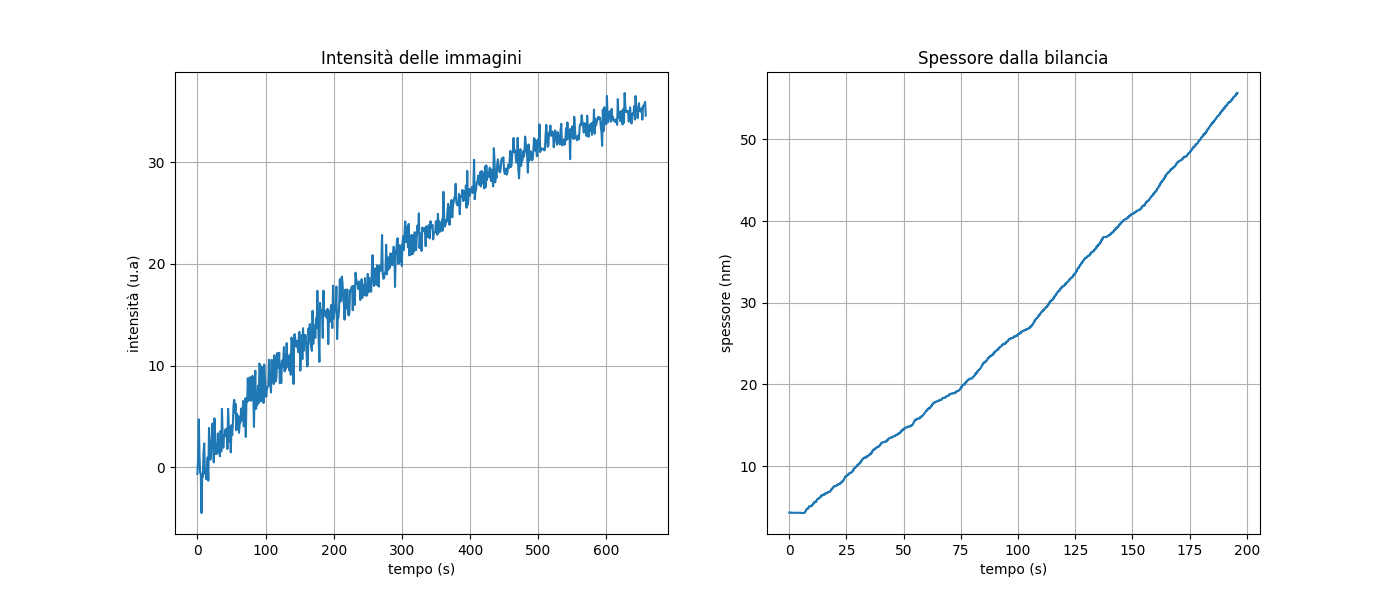

In [12]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,6))

ax1.plot(image_trel, mean_intensities)
ax1.set_title("Intensità delle immagini")
ax1.set_ylabel("intensità (u.a)")
ax1.set_xlabel("tempo (s)")
ax1.grid()

ax2.plot(bilancia_trel, bilancia_thicknesses)
ax2.set_title("Spessore dalla bilancia")
ax2.set_ylabel("spessore (nm)")
ax2.set_xlabel("tempo (s)")
ax2.grid()

plt.show

## Ipotesi di linearità fra i dati di intensità non filtrati e i dati di spessore dalla bilancia
### Verifico se l'andamento dei residui fra i dati di spessore predetto dalla camera e quelli misurati dalla bilancia è gaussiano (domina rumore bianco e l'intensità misurata è proporzionale allo spessore depositato)

In [13]:
# dati di intensità della camera limitati al tempo di misura della bilancia
interpolated_intensities = np.interp(bilancia_trel, image_trel, mean_intensities) 

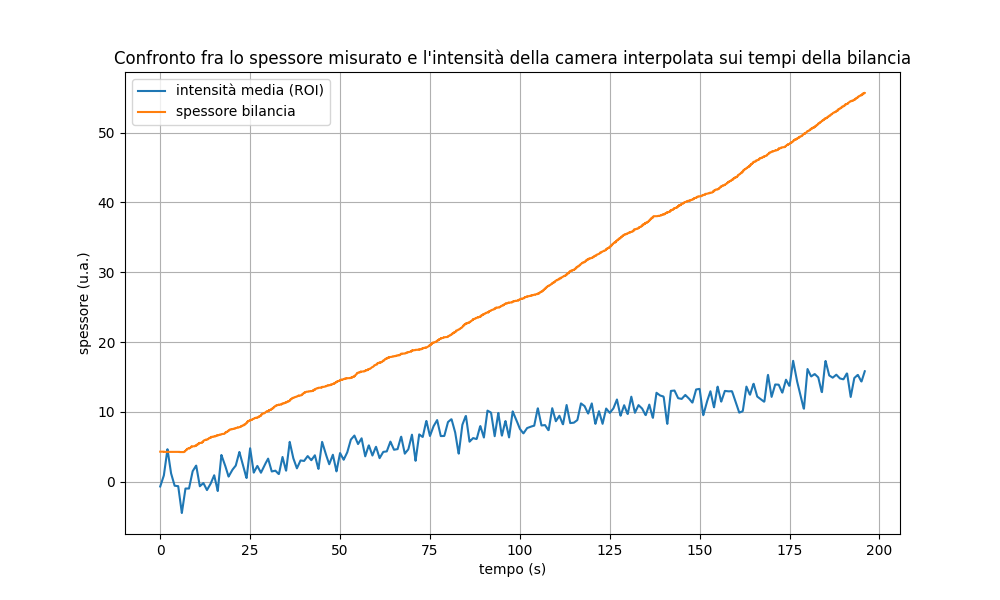

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(bilancia_trel, interpolated_intensities, label='intensità media (ROI)')
plt.plot(bilancia_trel, bilancia_thicknesses, label='spessore bilancia')
plt.title("Confronto fra lo spessore misurato e l'intensità della camera interpolata sui tempi della bilancia")
plt.xlabel("tempo (s)")
plt.ylabel("spessore (u.a.)")
plt.legend()
plt.grid()
plt.show()

In [15]:
# m e q forniscono i fattori di scala fra i dati raccolti dalla bilancia e quelli raccolti dalla camera
m, q = np.polyfit(interpolated_intensities, bilancia_thicknesses, 1) # o bilancia_thicknesses_masked se lavoriamo con i dati filtrati
print(f"Coefficiente angolare: {m}, intercetta: {q}")

Coefficiente angolare: 3.111497005207131, intercetta: 2.7838622284643613


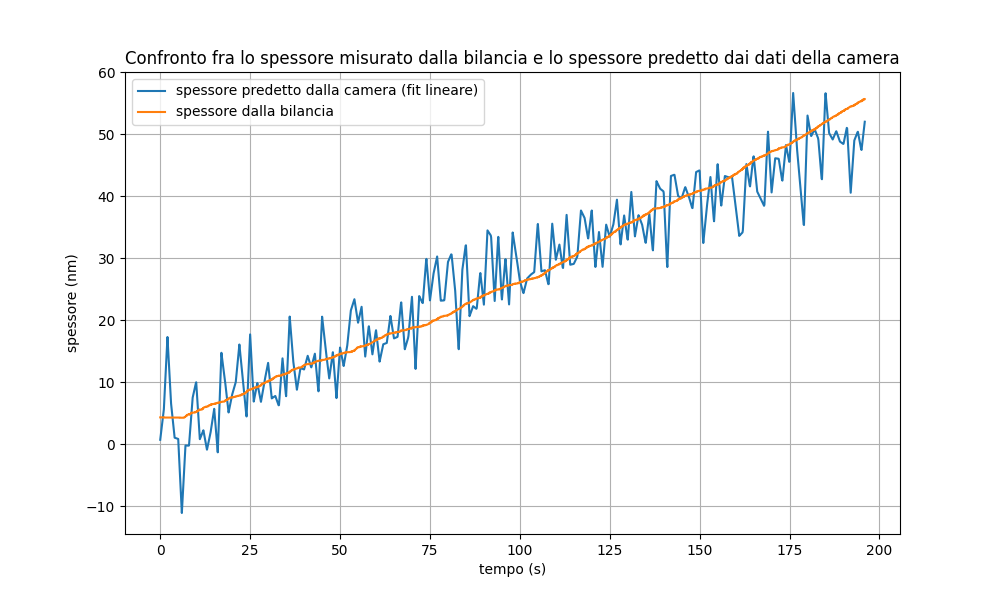

In [16]:
plt.figure(figsize=(10, 6))

predicted_camera_thicknesses = m * interpolated_intensities + q # questo è il dato di intensità "convertito" in spessore 

plt.plot(bilancia_trel, predicted_camera_thicknesses, label='spessore predetto dalla camera (fit lineare)')

plt.plot(bilancia_trel, bilancia_thicknesses, label='spessore dalla bilancia')

plt.xlabel('tempo (s)')
plt.ylabel('spessore (nm)') #era segnato lo spessore in mm, ho corretto in nm, era una svista?
plt.title("Confronto fra lo spessore misurato dalla bilancia e lo spessore predetto dai dati della camera")
plt.grid()
plt.legend()
plt.show()

8.335809554000337


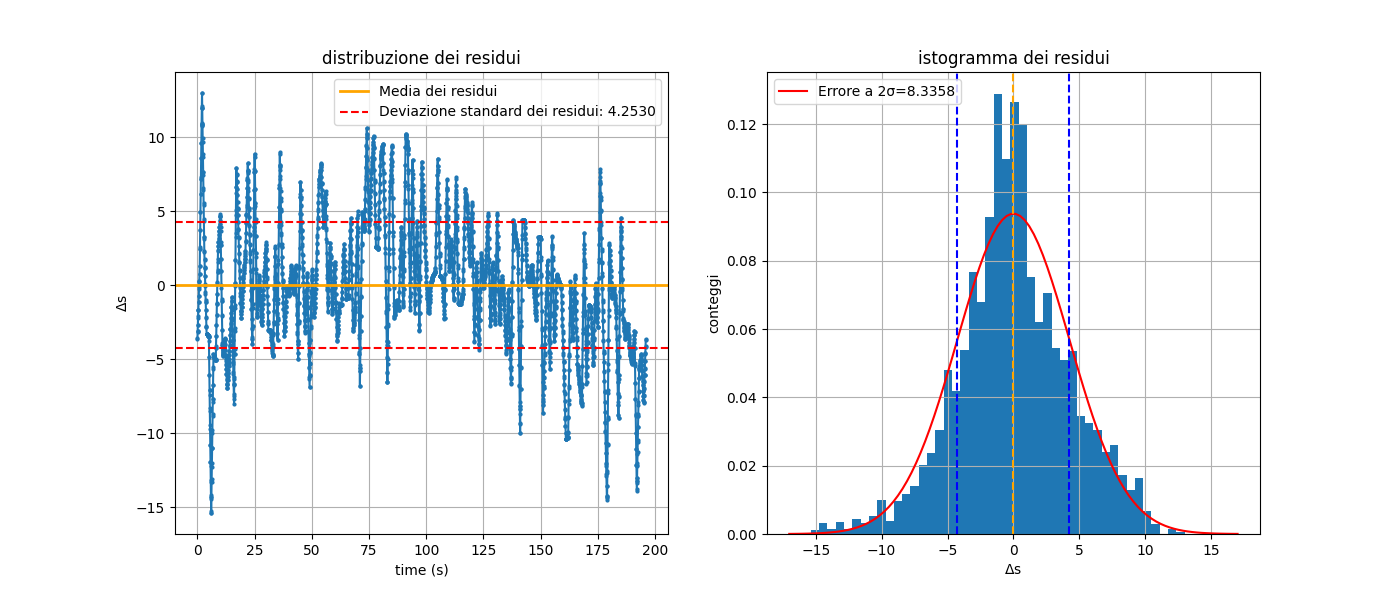

In [17]:
residui = predicted_camera_thicknesses - bilancia_thicknesses 

predicted_thicknesses_std = np.std((residui))  # deviazione standard dei residui del fit lineare
media_residui = np.mean(residui)

error_2sigma = 1.96*predicted_thicknesses_std
print(error_2sigma)

Nbins = round(len(residui)/100)

fig1, (ax1,ax2) = plt.subplots(1,2, figsize=(14,6))

ax1.plot(bilancia_trel, residui, marker='o', markersize='2')
ax1.set_title("distribuzione dei residui")
ax1.set_ylabel("$\Delta$s")
#ax1.set_ylim(bottom=-0.13, top=0.13) #RICORDARSI DI COMMENTARE LA "CADUTA" DEI DATI INTORNO A 30 S SE RIUSCIAMO A SPIEGARLA
ax1.set_xlabel("time (s)")
ax1.axhline(media_residui, color="orange", linestyle="-", label=f'Media dei residui', linewidth=2)
ax1.axhline(predicted_thicknesses_std, color="r", linestyle="--", label=f'Deviazione standard dei residui: {predicted_thicknesses_std:.4f}')
ax1.axhline(-predicted_thicknesses_std, color="r", linestyle='--')
ax1.legend()
ax1.grid()


ax2.hist(residui, Nbins, density=True)
ax2.set_ylabel("conteggi")
ax2.set_xlabel("$\Delta$s")
ax2.set_title("istogramma dei residui")
ax2.grid()

xs = np.linspace(-4*predicted_thicknesses_std, 4*predicted_thicknesses_std, 100)
ys = (1 / (predicted_thicknesses_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs) / predicted_thicknesses_std) ** 2)
ax2.plot(xs, ys, color='r' )
ax2.plot([], [], color='r', label=f'Errore a 2σ={error_2sigma:.4f}')
ax2.axvline(media_residui, color="orange", linestyle="--")
ax2.axvline(predicted_thicknesses_std, color="b", linestyle="--")
ax2.axvline(-predicted_thicknesses_std, color="b", linestyle='--')

ax2.legend(loc='upper left')
plt.show()

Dati 'calibrazione': non attribuisco un andamento gaussiano alla distribuzione dei residui. Non escludo il modello lineare, ma i residui non sono puro rumore casuale indipendente.  
Dati '29-04-2026': il rumore sembra gaussiano ma per coerenza proseguiamo ugualmente con l'analisi

## Analisi con i percentili per valutare impatto outliers

In [18]:
df_residui = pd.DataFrame(residui, columns=['Residui'])
#print(df_residui.shape)
percentili_target = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
tabella_percentili = df_residui['Residui'].quantile(percentili_target)
print(tabella_percentili)

0.01   -11.263761
0.05    -6.920044
0.25    -2.442029
0.50    -0.133557
0.75     2.618308
0.95     7.470248
0.99     9.541901
Name: Residui, dtype: float64


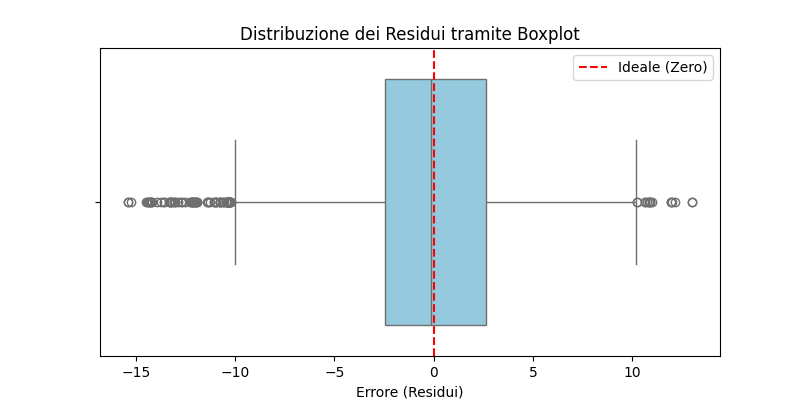

In [19]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_residui['Residui'], color='skyblue')

# la linea sullo zero indica dove dovrebbe stare la mediana ideal
plt.axvline(x=0, color='red', linestyle='--', label='Ideale (Zero)')
plt.title('Distribuzione dei Residui tramite Boxplot')
plt.xlabel('Errore (Residui)')
plt.legend()
plt.show()

In [20]:
""" verifico quali dati hanno un residuo molto negativo (il modello non li stima correttamente)
data = []
for i in range(len(residui)):
    if residui[i] < -0.13:
        data.append(bilancia_thicknesses[i])

data = np.array(data)
print(data.shape)

plt.figure(figsize=(10,6))
plt.hist(data)
plt.grid()
plt.show()
"""
    

' verifico quali dati hanno un residuo molto negativo (il modello non li stima correttamente)\ndata = []\nfor i in range(len(residui)):\n    if residui[i] < -0.13:\n        data.append(bilancia_thicknesses[i])\n\ndata = np.array(data)\nprint(data.shape)\n\nplt.figure(figsize=(10,6))\nplt.hist(data)\nplt.grid()\nplt.show()\n'

In [21]:
# --- Quantificazione del peso delle code rispetto al centro della distribuzione ---

# estraiamo i percentili già calcolati
p1  = tabella_percentili[0.01]
p5  = tabella_percentili[0.05]
p25 = tabella_percentili[0.25]
p50 = tabella_percentili[0.50]
p75 = tabella_percentili[0.75]
p95 = tabella_percentili[0.95]
p99 = tabella_percentili[0.99]

# ampiezza degli intervalli centrali e delle code
iqr        = p75 - p25   # range interquartile (50% centrale dei dati)
range_90   = p95 - p5    # 90% centrale
range_98   = p99 - p1    # 98% centrale

# rapporti: quanto le code sono "larghe" rispetto al nucleo centrale
rapporto_90_iqr = range_90 / iqr
rapporto_98_iqr = range_98 / iqr

# valori di riferimento attesi per una VERA gaussiana (calcolabili analiticamente, non dipendono dai tuoi dati, servono solo da confronto)
from scipy.stats import norm
iqr_gauss      = norm.ppf(0.75) - norm.ppf(0.25)
range90_gauss  = norm.ppf(0.95) - norm.ppf(0.05)
range98_gauss  = norm.ppf(0.99) - norm.ppf(0.01)

rapporto_90_iqr_gauss = range90_gauss / iqr_gauss
rapporto_98_iqr_gauss = range98_gauss / iqr_gauss

print(f"IQR (25%-75%):         {iqr:.4f}")
print(f"Range 90% (5%-95%):    {range_90:.4f}")
print(f"Range 98% (1%-99%):    {range_98:.4f}")
print()
print(f"Rapporto range90/IQR:  {rapporto_90_iqr:.3f}   (atteso per gaussiana: {rapporto_90_iqr_gauss:.3f})")
print(f"Rapporto range98/IQR:  {rapporto_98_iqr:.3f}   (atteso per gaussiana: {rapporto_98_iqr_gauss:.3f})")

# quanto ci discostiamo, in percentuale, dal valore atteso gaussiano
eccesso_90 = (rapporto_90_iqr / rapporto_90_iqr_gauss - 1) * 100
eccesso_98 = (rapporto_98_iqr / rapporto_98_iqr_gauss - 1) * 100
print()
print(f"Eccesso rispetto a gaussiana (range90/IQR): {eccesso_90:+.1f}%")
print(f"Eccesso rispetto a gaussiana (range98/IQR): {eccesso_98:+.1f}%")

# indice di simmetria delle code (Bowley skewness), utile per la tabella
bowley_skew = (p75 + p25 - 2*p50) / iqr
print(f"\nAsimmetria di Bowley: {bowley_skew:.4f}  (0 = simmetrica, <0 = coda pesante a sinistra)")

IQR (25%-75%):         5.0603
Range 90% (5%-95%):    14.3903
Range 98% (1%-99%):    20.8057

Rapporto range90/IQR:  2.844   (atteso per gaussiana: 2.439)
Rapporto range98/IQR:  4.112   (atteso per gaussiana: 3.449)

Eccesso rispetto a gaussiana (range90/IQR): +16.6%
Eccesso rispetto a gaussiana (range98/IQR): +19.2%

Asimmetria di Bowley: 0.0876  (0 = simmetrica, <0 = coda pesante a sinistra)


Se i rapporti range90/IQR e range98/IQR sono sensibilmente più alti di questi valori di riferimento, significa che le code sono più pesanti di quelle di una gaussiana — cioè hai più outlier/eventi estremi di quanti un rumore puramente gaussiano ne produrrebbe, a parità di dispersione centrale.

L'asimmetria di Bowley è calcolata solo sui quartili (25%-75%), quindi è per costruzione robusta agli outlier estremi (non evidenza la coda sui residui negativi visibile dal boxplot)

In [22]:
# troviamo tutti i punti con residuo oltre una soglia (es. 3 volte l'IQR dal centro)
soglia = 3 * iqr  # criterio robusto, alternativo a "4 sigma" usato prima
outlier_mask = np.abs(residui - np.median(residui)) > soglia
outlier_times = bilancia_trel[outlier_mask]
outlier_values = residui[outlier_mask]

print(f"Numero totale di punti anomali: {outlier_mask.sum()} su {len(residui)}")

# raggruppiamo i tempi anomali in cluster (eventi separati)
if len(outlier_times) > 0:
    sorted_times = np.sort(outlier_times)
    gaps = np.diff(sorted_times)
    cluster_breaks = np.where(gaps > 2)[0]  # se il gap fra due outlier è >2s, sono eventi diversi
    
    cluster_starts = np.concatenate(([sorted_times[0]], sorted_times[cluster_breaks + 1]))
    cluster_ends = np.concatenate((sorted_times[cluster_breaks], [sorted_times[-1]]))
    
    print(f"\nNumero di eventi/cluster distinti: {len(cluster_starts)}")
    for cs, ce in zip(cluster_starts, cluster_ends):
        n_points = np.sum((outlier_times >= cs) & (outlier_times <= ce))
        max_abs_val = np.max(np.abs(outlier_values[(outlier_times >= cs) & (outlier_times <= ce)]))
        print(f"  Evento: t = {cs:.2f}s - {ce:.2f}s  ({n_points} punti, |residuo| max = {max_abs_val:.4f})")

Numero totale di punti anomali: 2 su 4480

Numero di eventi/cluster distinti: 1
  Evento: t = 6.01s - 6.01s  (2 punti, |residuo| max = 15.3780)


In [23]:
# costruiamo la maschera di esclusione direttamente dai cluster trovati in cella 25,
# invece di scrivere a mano gli intervalli (fonte di errori/bug come prima)

margine = 1  # secondi di margine attorno a ciascun cluster, per sicurezza

mask_no_outliers = np.ones_like(bilancia_trel, dtype=bool)

for cs, ce in zip(cluster_starts, cluster_ends):
    mask_no_outliers &= ~((bilancia_trel >= cs - margine) & (bilancia_trel <= ce + margine))

print(f"Punti totali: {len(residui)}")
print(f"Punti esclusi: {(~mask_no_outliers).sum()} ({100*(~mask_no_outliers).sum()/len(residui):.2f}%)")
print(f"Cluster esclusi: {len(cluster_starts)}")
for cs, ce in zip(cluster_starts, cluster_ends):
    print(f"  t = {cs:.4f}s - {ce:.4f}s")

residui_clean2 = residui[mask_no_outliers]

df_clean2 = pd.DataFrame(residui_clean2, columns=['Residui'])
tabella_percentili_clean = df_clean2['Residui'].quantile(percentili_target)

Punti totali: 4480
Punti esclusi: 45 (1.00%)
Cluster esclusi: 1
  t = 6.0111s - 6.0111s


In [24]:
# estraiamo i percentili già calcolati
p1  = tabella_percentili_clean[0.01]
p5  = tabella_percentili_clean[0.05]
p25 = tabella_percentili_clean[0.25]
p50 = tabella_percentili_clean[0.50]
p75 = tabella_percentili_clean[0.75]
p95 = tabella_percentili_clean[0.95]
p99 = tabella_percentili_clean[0.99]

# ampiezza degli intervalli centrali e delle code
iqr        = p75 - p25   # range interquartile (50% centrale dei dati)
range_90   = p95 - p5    # 90% centrale
range_98   = p99 - p1    # 98% centrale

# rapporti: quanto le code sono "larghe" rispetto al nucleo centrale
rapporto_90_iqr = range_90 / iqr
rapporto_98_iqr = range_98 / iqr

# valori di riferimento attesi per una VERA gaussiana (calcolabili analiticamente,
# non dipendono dai tuoi dati, servono solo da confronto)
from scipy.stats import norm
iqr_gauss      = norm.ppf(0.75) - norm.ppf(0.25)
range90_gauss  = norm.ppf(0.95) - norm.ppf(0.05)
range98_gauss  = norm.ppf(0.99) - norm.ppf(0.01)

rapporto_90_iqr_gauss = range90_gauss / iqr_gauss
rapporto_98_iqr_gauss = range98_gauss / iqr_gauss

print(f"IQR (25%-75%):         {iqr:.4f}")
print(f"Range 90% (5%-95%):    {range_90:.4f}")
print(f"Range 98% (1%-99%):    {range_98:.4f}")
print()
print(f"Rapporto range90/IQR:  {rapporto_90_iqr:.3f}   (atteso per gaussiana: {rapporto_90_iqr_gauss:.3f})")
print(f"Rapporto range98/IQR:  {rapporto_98_iqr:.3f}   (atteso per gaussiana: {rapporto_98_iqr_gauss:.3f})")

# quanto ci discostiamo, in percentuale, dal valore atteso gaussiano
eccesso_90 = (rapporto_90_iqr / rapporto_90_iqr_gauss - 1) * 100
eccesso_98 = (rapporto_98_iqr / rapporto_98_iqr_gauss - 1) * 100
print()
print(f"Eccesso rispetto a gaussiana (range90/IQR): {eccesso_90:+.1f}%")
print(f"Eccesso rispetto a gaussiana (range98/IQR): {eccesso_98:+.1f}%")

# indice di simmetria delle code (Bowley skewness), utile per la tabella
bowley_skew = (p75 + p25 - 2*p50) / iqr
print(f"\nAsimmetria di Bowley: {bowley_skew:.4f}  (0 = simmetrica, <0 = coda pesante a sinistra)")

IQR (25%-75%):         4.9954
Range 90% (5%-95%):    14.0909
Range 98% (1%-99%):    19.8925

Rapporto range90/IQR:  2.821   (atteso per gaussiana: 2.439)
Rapporto range98/IQR:  3.982   (atteso per gaussiana: 3.449)

Eccesso rispetto a gaussiana (range90/IQR): +15.7%
Eccesso rispetto a gaussiana (range98/IQR): +15.5%

Asimmetria di Bowley: 0.0911  (0 = simmetrica, <0 = coda pesante a sinistra)


Dati 'calibrazione': gli eccessi migliorano, ma non abbiamo risolto il problema dell'asimmetria delle code.
I dati grezzi della bilancia nella finestra mask_no_outliers sono una scala a gradini regolare (quantizzata a step di 0.001 nm, risoluzione dello strumento), monotona crescente, senza salti né anomalie.

In [25]:
anomaly_time_range = (image_trel > 38) & (image_trel < 42)
anomaly_idx = np.where(anomaly_time_range)[0]

print("Tempi:", image_trel[anomaly_idx])
print("Intensità media (ROI):", mean_intensities[anomaly_idx])
print("Differenze frame-to-frame:", np.diff(mean_intensities[anomaly_idx]))

Tempi: [39. 40. 41.]
Intensità media (ROI): [3.05775656 2.97501989 3.69101034]
Differenze frame-to-frame: [-0.08273667  0.71599045]


Dati 'calibrazione': risulta evidente che nel frame 40 l'intensità cala anche se non si spiega il motivo (togliendo questo range temporale dai residui, infatti, migliora il confronto delle code rispetto a quelle di una gaussiana)  
Dati '29-04-2026': non sembra esserci una variazione che giustifichi la rimozione dei dati individuati

In [26]:
# invece di "predicted ± 2*sigma" (assume gaussianità)
# usa direttamente i percentili empirici dei residui come intervallo di confidenza
ci_lower = tabella_percentili[0.05]  # 5° percentile
ci_upper = tabella_percentili[0.95]  # 95° percentile

print(f"Intervallo di confidenza al 90% (empirico, non-parametrico): [{ci_lower:.3f}, {ci_upper:.3f}]")

Intervallo di confidenza al 90% (empirico, non-parametrico): [-6.920, 7.470]


In [27]:
X = interpolated_intensities.reshape(-1,1)
y = bilancia_thicknesses 

huber = HuberRegressor().fit(X, y)
print(f"Huber - slope: {huber.coef_[0]:.4f}, intercept: {huber.intercept_:.4f}")

theilsen = TheilSenRegressor().fit(X, y)
print(f"Theil-Sen - slope: {theilsen.coef_[0]:.4f}, intercept: {theilsen.intercept_:.4f}")

# confronta con il fit OLS classico che avevi già
print(f"OLS (originale) - slope: {m:.4f}, intercept: {q:.4f}")

Huber - slope: 3.0937, intercept: 2.9686


Theil-Sen - slope: 2.9951, intercept: 3.1794
OLS (originale) - slope: 3.1115, intercept: 2.7839


## Individuo finestra ottimale con deviazione di Allan

L'analisi della deviazione di Allan vuole rispondere alla domanda:"per quanto tempo devo mediare per ridurre il rumore, prima che l'averaging inizi a distorcere la vera dinamica del segnale?". Quando la finestra diventa comparabile alla scala temporale della dinamica fisica (il rate di deposizione), la finestra non riduce più l'errore, anzi lo aumenta introducendo distorsione (bias). Il grafico della deviazione di Allan in funzione della finestra (τ) mostra tipicamente una curva a "V": scende con pendenza -1/2 in scala log-log finché domina il rumore bianco, poi risale (o si appiattisce) quando inizia a dominare la dinamica del segnale. Il minimo di questa curva è, per costruzione, la finestra ottimale.

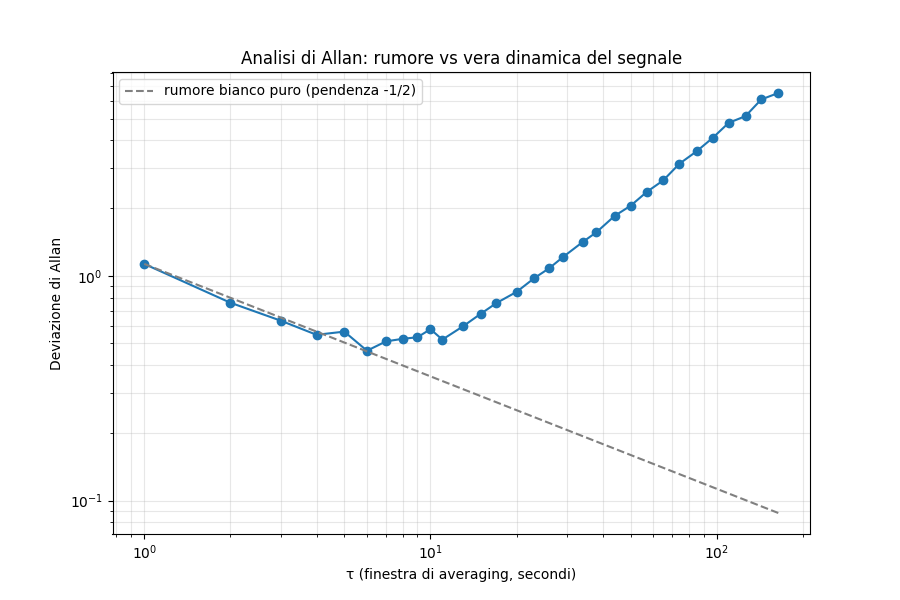

Finestra ottimale: τ = 6.0s (6 frame)


In [28]:
def allan_deviation(data, max_m=None):
    """
    Calcola la deviazione di Allan per un array di dati campionati a intervalli regolari.
    m = dimensione della finestra di averaging (in numero di campioni)
    """
    n = len(data)
    if max_m is None:
        max_m = n // 4  # serve un numero ragionevole di finestre indipendenti per ogni m
    
    ms = np.unique(np.logspace(0, np.log10(max_m), 40).astype(int))
    ms = ms[ms >= 1]
    
    taus = []
    allan_vars = []
    
    for m in ms:
        # numero di finestre non sovrapposte di lunghezza m
        n_windows = n // m
        if n_windows < 3:  # serve almeno un paio di differenze per stimare la varianza
            continue
        
        # medie di ogni finestra
        means = np.array([np.mean(data[i*m:(i+1)*m]) for i in range(n_windows)])
        
        # deviazione di Allan: metà della varianza delle differenze fra medie consecutive
        diffs = np.diff(means)
        allan_var = 0.5 * np.mean(diffs**2)
        
        taus.append(m)  # in campioni; moltiplica per dt per avere secondi
        allan_vars.append(allan_var)
    
    return np.array(taus), np.sqrt(np.array(allan_vars))


# usiamo il segnale grezzo, ESCLUDENDO i due eventi anomali già identificati
mask_clean = np.ones_like(image_trel, dtype=bool)
for cs, ce in zip(cluster_starts, cluster_ends):
    mask_clean &= ~((image_trel >= cs - margine) & (image_trel <= ce + margine))

signal_clean = mean_intensities[mask_clean]

dt = np.mean(np.diff(image_trel))  # ~1s
taus_samples, allan_dev = allan_deviation(signal_clean)
taus_seconds = taus_samples * dt

plt.figure(figsize=(9,6))
plt.loglog(taus_seconds, allan_dev, marker='o')
plt.xlabel("τ (finestra di averaging, secondi)")
plt.ylabel("Deviazione di Allan")
plt.title("Analisi di Allan: rumore vs vera dinamica del segnale")
plt.grid(which='both', alpha=0.3)

# riferimento: andamento atteso per puro rumore bianco (pendenza -1/2)
ref = allan_dev[0] * np.sqrt(taus_seconds[0] / taus_seconds)
plt.loglog(taus_seconds, ref, '--', color='gray', label='rumore bianco puro (pendenza -1/2)')
plt.legend()
plt.show()

# finestra ottimale: minimo della curva
idx_min = np.argmin(allan_dev)
print(f"Finestra ottimale: τ = {taus_seconds[idx_min]:.1f}s "
      f"({taus_samples[idx_min]} frame)")

Caveat: fra le ipotesi per applicare questa analisi serve stazionarietà (almeno locale) del processo di rumore, ci serve che il segnale non abbia un trend deterministico, cosa che invece ha! Applichiamo un detrend lineare: se la curva continua a risalire in modo marcato anche dopo il detrend, questo sarebbe un'evidenza di una componente strutturata a piccola scala temporale che il fit lineare non cattura e non rimuove.

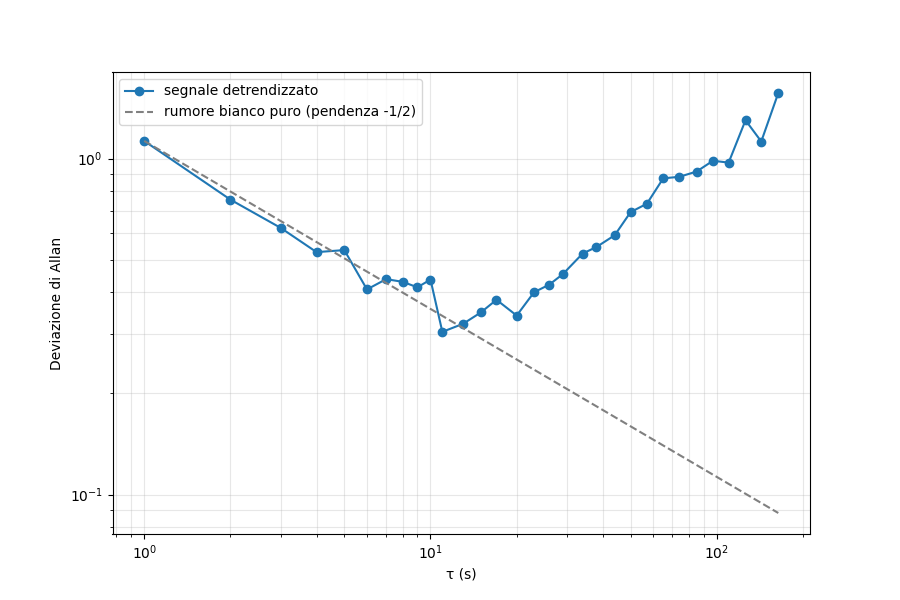

In [29]:
# rimuoviamo il trend lineare di fondo prima di calcolare Allan
t_clean = image_trel[mask_clean]
signal_raw = mean_intensities[mask_clean]

fit_coefs = np.polyfit(t_clean, signal_raw, 1) 
signal_detrended = signal_raw - np.polyval(fit_coefs, t_clean)

taus_samples, allan_dev_detrended = allan_deviation(signal_detrended)
taus_seconds = taus_samples * dt

plt.figure(figsize=(9,6))
plt.loglog(taus_seconds, allan_dev_detrended, marker='o', label='segnale detrendizzato')
ref = allan_dev_detrended[0] * np.sqrt(taus_seconds[0] / taus_seconds)
plt.loglog(taus_seconds, ref, '--', color='gray', label='rumore bianco puro (pendenza -1/2)')
plt.xlabel("τ (s)")
plt.ylabel("Deviazione di Allan")
plt.legend()
plt.grid(which='both', alpha=0.3)
plt.show()

Dati 'calibrazione': la discesa iniziale (τ=1→4s) ora segue in modo più aderente la retta di riferimento del rumore bianco (pendenza -1/2). Questo conferma che a scale brevissime il segnale è dominato da rumore bianco frame-to-frame. Il plateau visibile fra τ≈4s e τ≈11s è il segno di una zona di transizione dove il rumore bianco si sta esaurendo ma la dinamica non è ancora dominante. Abbiamo una finestra più ampia e più comoda da scegliere rispetto al minimo netto di prima. L'ultimo tratto (oltre τ≈200s) scende bruscamente — questo però è quasi certamente un artefatto di bordo, non un fenomeno fisico: a quelle finestre così ampie, sul dataset di ~1000s si hanno solo 4-5 finestre indipendenti disponibili per stimare la varianza, quindi la statistica è inaffidabile.

Proviamo a fare il detrend non con una singola retta, ma con un polinomio di grado più alto (es. grado 3-4) o con uno spline morbido, che catturi la curvatura lenta del trend reale senza rimuovere l'oscillazione più veloce

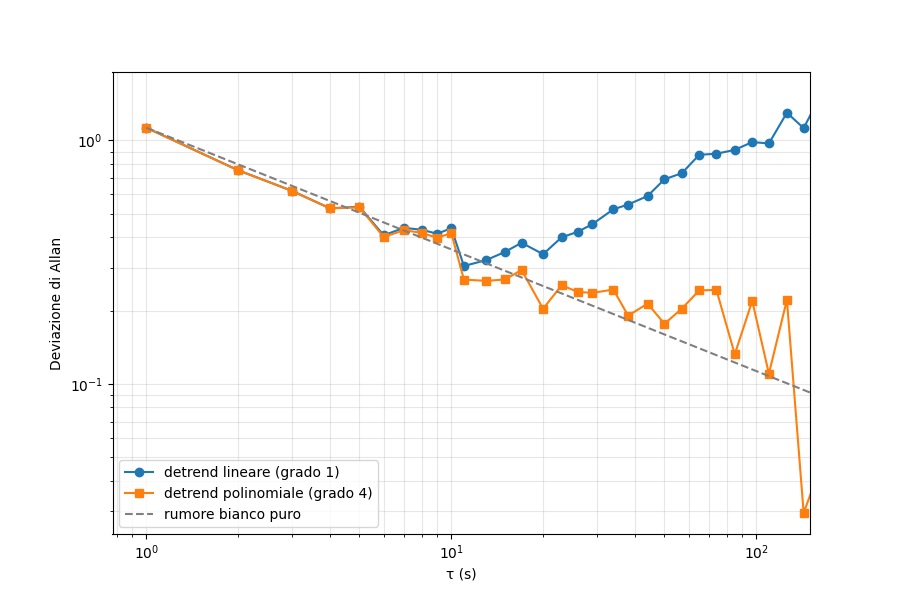

In [30]:
fit_coefs_poly = np.polyfit(t_clean, signal_raw, deg=4)
signal_detrended_poly = signal_raw - np.polyval(fit_coefs_poly, t_clean)

taus_samples2, allan_dev_poly = allan_deviation(signal_detrended_poly)
taus_seconds2 = taus_samples2 * dt

plt.figure(figsize=(9,6))
plt.loglog(taus_seconds, allan_dev_detrended, marker='o', label='detrend lineare (grado 1)')
plt.loglog(taus_seconds2, allan_dev_poly, marker='s', label='detrend polinomiale (grado 4)')
ref = allan_dev_detrended[0] * np.sqrt(taus_seconds[0] / taus_seconds)
plt.loglog(taus_seconds, ref, '--', color='gray', label='rumore bianco puro')
plt.xlabel("τ (s)"); plt.ylabel("Deviazione di Allan"); plt.legend()
plt.grid(which='both', alpha=0.3)
plt.xlim(right=150)  # escludiamo la zona con troppo poche finestre indipendenti
plt.show()

Dati 'calibrazione': la risalita fra 15 e 100s è in parte un artefatto residuo del non aver rimosso perfettamente la curvatura lenta del trend di deposizione (visibile perché il detrend più flessibile la attenua), e in parte — quella porzione che resta anche col detrend polinomiale — un'evidenza di una vera dinamica strutturata a quelle scale.  
Il plateau (τ≈4-15s, che qui appare ancora più netto e allargato con entrambi i detrend) resta la zona più difendibile per scegliere la finestra.

N.B: un detrend polinomiale di grado 4 può esso stesso "mangiarsi" parte di un'oscillazione lenta genuina se il periodo dell'oscillazione è paragonabile alla scala di variazione del polinomio — quindi il fatto che la curva arancione sia più bassa non prova del tutto che il surplus fosse "solo trend": un polinomio flessibile può assorbire anche un po' di oscillazione vera.

## Ipotesi di linearità fra i dati di intensità con media mobile a peso gaussiano e i dati di spessore dalla bilancia

In [31]:
window_size = 6
sigma = window_size / 2


difference_images_smooth = moving_average_images_gaussian_weights(difference_images, window_size, sigma)
#mean_intensities_smooth = np.mean(images_smooth, axis=(1, 2))
mean_intensities_smooth = np.array(compute_mean(difference_images_smooth, roi_mask))

In [32]:
print(mean_intensities_smooth.shape)

(659,)


In [33]:
#mean_intensities_smooth_sp = gaussian_filter1d(mean_intensities, sigma=5, mode='nearest')

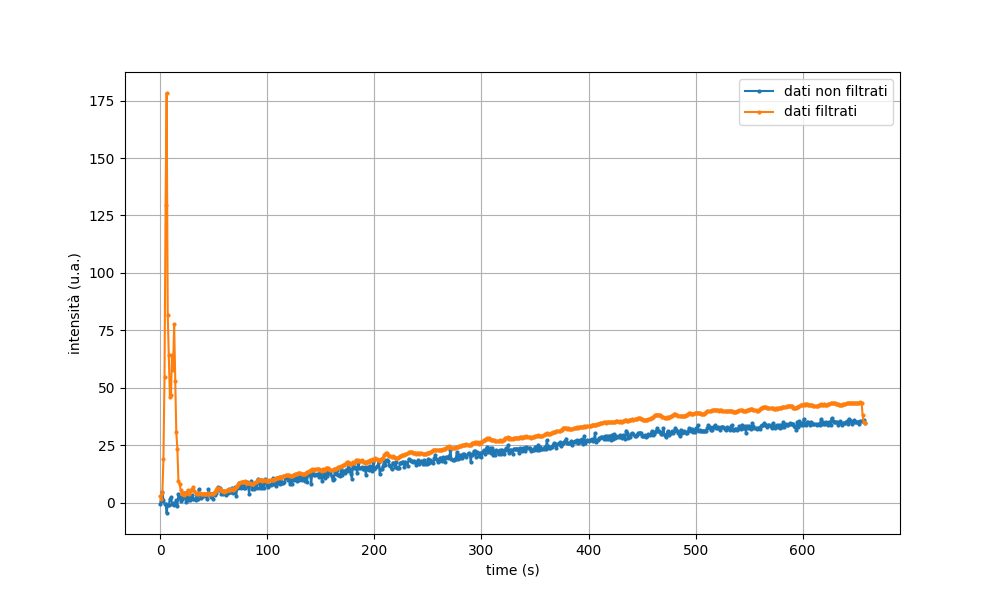

In [34]:
plt.figure(figsize=(10,6))
plt.plot(image_trel, mean_intensities, label=f"dati non filtrati", marker="o", markersize="2")
plt.plot(image_trel, mean_intensities_smooth, label=f"dati filtrati",marker="o", markersize="2")
plt.xlabel("time (s)")
plt.ylabel("intensità (u.a.)")
plt.grid()
plt.legend()
plt.show()


In [35]:
print(mean_intensities[-1] - mean_intensities[0])

35.24582338902148


In [36]:
print(f"spessori raccolti dalla bilancia= {bilancia_trel.shape}")
print(f"intensità raccolte dalla camera= {image_trel.shape}")
print(f"ultimo dato temporale per la bilancia= {bilancia_trel[-1]}")
print(f"ultimo dato temporale per la camera= {image_trel[-1]}")

spessori raccolti dalla bilancia= (4480,)
intensità raccolte dalla camera= (659,)
ultimo dato temporale per la bilancia= 195.9280548095703
ultimo dato temporale per la camera= 658.0


In [37]:
t0 = bilancia_timestamps[0]
tf = bilancia_timestamps[-1]


image_time_mask = (image_seconds >= t0) & (image_seconds <= tf)
image_trel = image_seconds[image_time_mask] - t0
mean_intensities_masked = mean_intensities_smooth[image_time_mask]

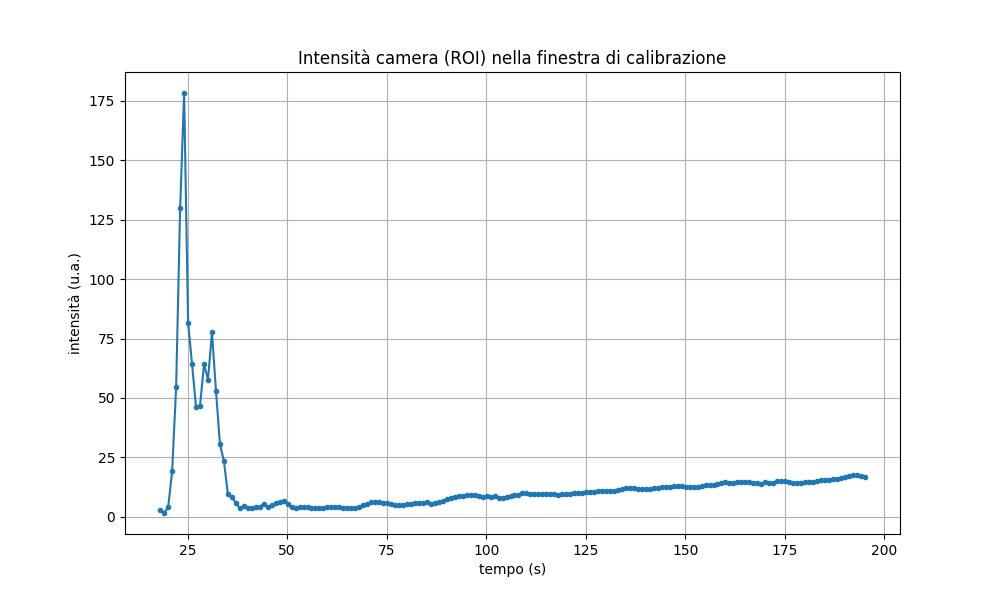

In [38]:
plt.figure(figsize=(10,6))
plt.plot(image_trel, mean_intensities_masked, marker='o', markersize=3)
plt.title("Intensità camera (ROI) nella finestra di calibrazione")
plt.xlabel("tempo (s)")
plt.ylabel("intensità (u.a.)")
plt.grid()
plt.show()

In [39]:
#t0 = bilancia_timestamps[0]+90
t0 = bilancia_timestamps[0]+75
tf = bilancia_timestamps[-1]


image_time_mask = (image_seconds >= t0) & (image_seconds <= tf)
image_trel = image_seconds[image_time_mask] - t0
mean_intensities_masked = np.array(mean_intensities_smooth[image_time_mask])


bilancia_time_mask = (bilancia_timestamps >= t0) & (bilancia_timestamps <= tf)
bilancia_trel = bilancia_timestamps[bilancia_time_mask] - t0
bilancia_thicknesses_masked = bilancia_thicknesses[bilancia_time_mask] 

In [40]:
interpolated_intensities_smooth = np.interp(bilancia_trel, image_trel, mean_intensities_masked)

In [41]:
print(interpolated_intensities_smooth.shape)
print(mean_intensities_masked.shape)
print(bilancia_thicknesses_masked.shape)

(2766,)
(121,)
(2766,)


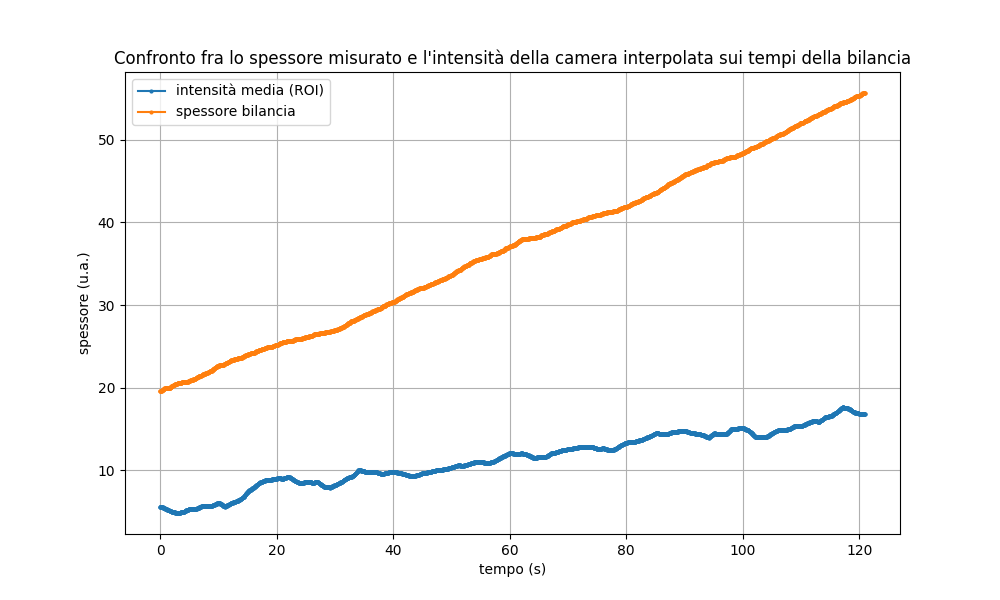

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(bilancia_trel, interpolated_intensities_smooth, label='intensità media (ROI)', marker='o', markersize=2)
plt.plot(bilancia_trel, bilancia_thicknesses_masked, label='spessore bilancia', marker='o', markersize=2)
plt.title("Confronto fra lo spessore misurato e l'intensità della camera interpolata sui tempi della bilancia")
plt.xlabel("tempo (s)")
plt.ylabel("spessore (u.a.)")
plt.legend()
plt.grid()
plt.show()

In [43]:
slope, intercept, error = lin_fit_with_error(interpolated_intensities_smooth, bilancia_thicknesses_masked)
print(f"coefficiente angolare= {slope:.4f}, intercetta= {intercept:.4f}")

coefficiente angolare= 3.0910, intercetta= 1.7772


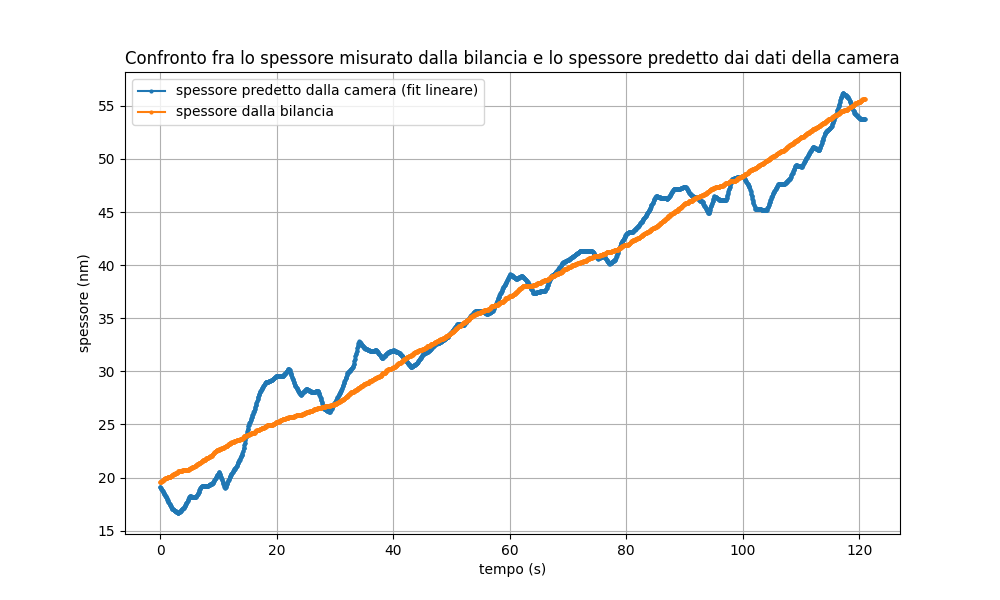

In [83]:
plt.figure(figsize=(10, 6))

predicted_camera_thicknesses_smooth = slope * interpolated_intensities_smooth + intercept # questo è il dato di intensità "convertito" in spessore 

plt.plot(bilancia_trel, predicted_camera_thicknesses_smooth, label='spessore predetto dalla camera (fit lineare)', marker='o', markersize='2')

plt.plot(bilancia_trel, bilancia_thicknesses_masked, label='spessore dalla bilancia', marker='o', markersize='2')

plt.xlabel('tempo (s)')
plt.ylabel('spessore (nm)') #era segnato lo spessore in mm, ho corretto in nm, era una svista?
plt.title("Confronto fra lo spessore misurato dalla bilancia e lo spessore predetto dai dati della camera")
plt.grid()
plt.legend()
plt.savefig('t_cam_and_t_bil.pdf')
plt.show()

errore a 2sigma= 2.4099
4.181188087083447
-3.832859924533552


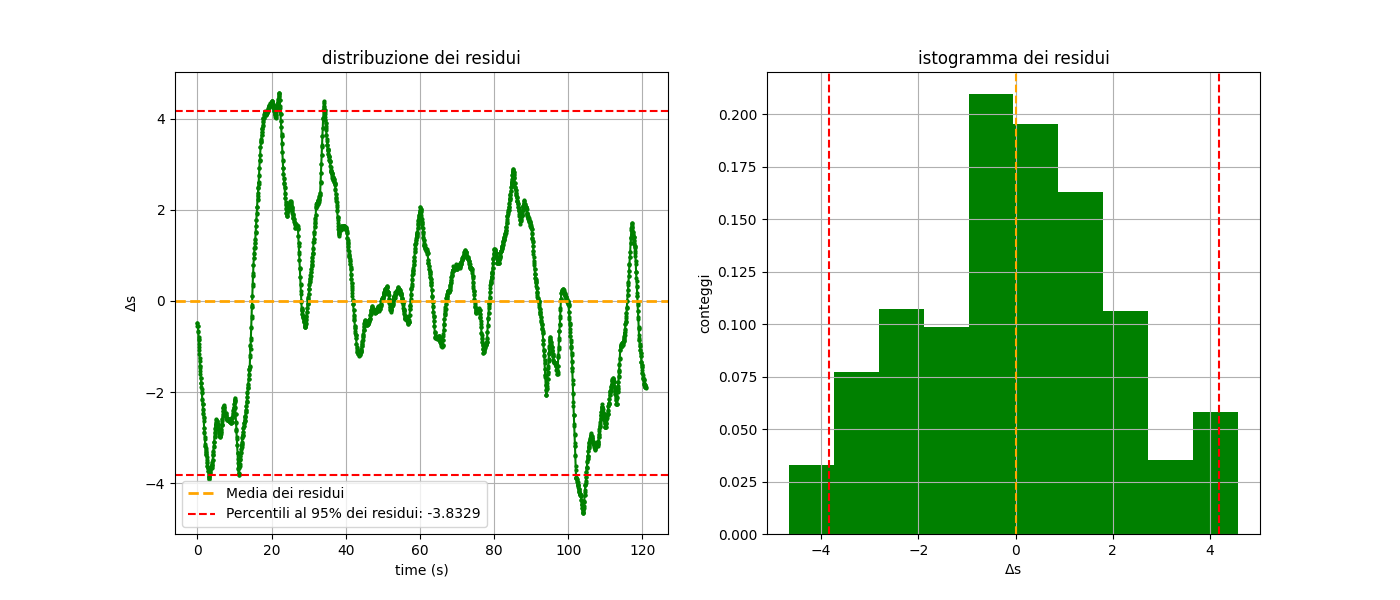

In [82]:
residui_smooth = predicted_camera_thicknesses_smooth - bilancia_thicknesses_masked

predicted_thicknesses_smooth_std = np.std(abs(residui_smooth))  # deviazione standard dei residui del fit lineare
media_residui_smooth = np.mean(residui_smooth)

error_2sigma_smooth = 1.96*predicted_thicknesses_smooth_std
print(f"errore a 2sigma= {error_2sigma_smooth:.4f}")

Nbins = round(len(residui_smooth)/270)

fig1, (ax1,ax2) = plt.subplots(1,2, figsize=(14,6))

ax1.plot(bilancia_trel, residui_smooth, marker='o', markersize='2', color='green')
ax1.set_title("distribuzione dei residui")
ax1.set_ylabel("$\Delta$s")
#ax1.set_ylim(bottom=-0.13, top=0.13) #RICORDARSI DI COMMENTARE LA "CADUTA" DEI DATI INTORNO A 30 S SE RIUSCIAMO A SPIEGARLA
ax1.set_xlabel("time (s)")
ax1.axhline(media_residui_smooth, color="orange", linestyle="--", label=f'Media dei residui', linewidth=2)
#ax1.axhline(predicted_thicknesses_smooth_std, color="r", linestyle="--", label=f'Deviazione standard dei residui: {predicted_thicknesses_smooth_std:.4f}')
#ax1.axhline(-predicted_thicknesses_smooth_std, color="r", linestyle='--')



ax2.hist(residui_smooth, Nbins, density=True, color='green')
ax2.set_ylabel("conteggi")
ax2.set_xlabel("$\Delta$s")
ax2.set_title("istogramma dei residui")


#xs = np.linspace(-4*predicted_thicknesses_std, 4*predicted_thicknesses_std, 100)
#ys = (1 / (predicted_thicknesses_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs) / predicted_thicknesses_std) ** 2)
#ax2.plot(xs, ys, color='r' )
#ax2.plot([], [], color='r', label=f'Errore a 2σ={error_2sigma:.4f}')
ax2.axvline(media_residui_smooth, color="orange", linestyle="--")
#ax2.axvline(predicted_thicknesses_smooth_std, color="b", linestyle="--")
#ax2.axvline(-predicted_thicknesses_smooth_std, color="b", linestyle='--')

perc_right = np.percentile(residui_smooth,97.5)
perc_left = np.percentile(residui_smooth,2.5)
print(perc_right)
print(perc_left)

ax2.axvline(perc_right, color="r", linestyle="--")
ax2.axvline(perc_left, color="r", linestyle="--")

ax1.axhline(perc_left, color="r", linestyle="--", label=f'Percentili al 95% dei residui: {perc_left:.4f}')
ax1.axhline(perc_right, color="r", linestyle="--")

ax1.legend()
ax1.grid()

#ax2.legend()
ax2.grid()

fig1.savefig('calibrazione.pdf')

plt.show()



La distribuzione dei residui è decisamente non gaussiana.
Un residuo strutturato e periodico come questo è tipicamente il segno di:
- interferenza a film sottile — se l'intensità riflessa che stai misurando con la camera dipende dallo spessore in modo non lineare (oscillazioni di interferenza ottica tipiche nella deposizione di film sottili monitorata otticamente), un fit lineare lascerà residui oscillanti esattamente di questo tipo;
- un effetto periodico strumentale (es. drift termico ciclico, vibrazioni, un artefatto di acquisizione con un certo periodo).

### L'andamento lineare ipotizzato è corretto?

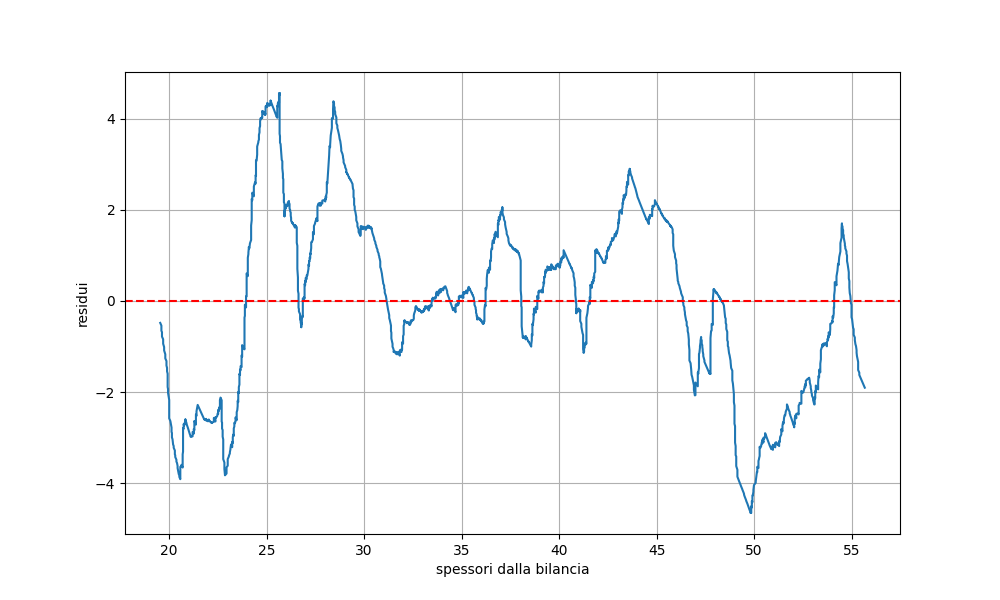

In [46]:
plt.figure(figsize=(10,6))
plt.plot(bilancia_thicknesses_masked, residui_smooth)
plt.xlabel("spessori dalla bilancia")
plt.ylabel("residui")
plt.axhline(0, linestyle='--', color='r')
plt.grid()
plt.show()

Si vede che la telecamera sovrastima o sottostima il dato di spessore raccolto dalla bilancia. Aver filtrato i dati evidenzia che l'ipotesi lineare non è sufficiente a calibrare i dati di telecamera e bilancia.  
Provo a vedere se esiste un delay costante fra le due serie temporali calcolando la cross-correlazione. In presenza di un delay temporale fisso, bisognerebbe riallineare le serie prima di filtrare i dati o interpolare.

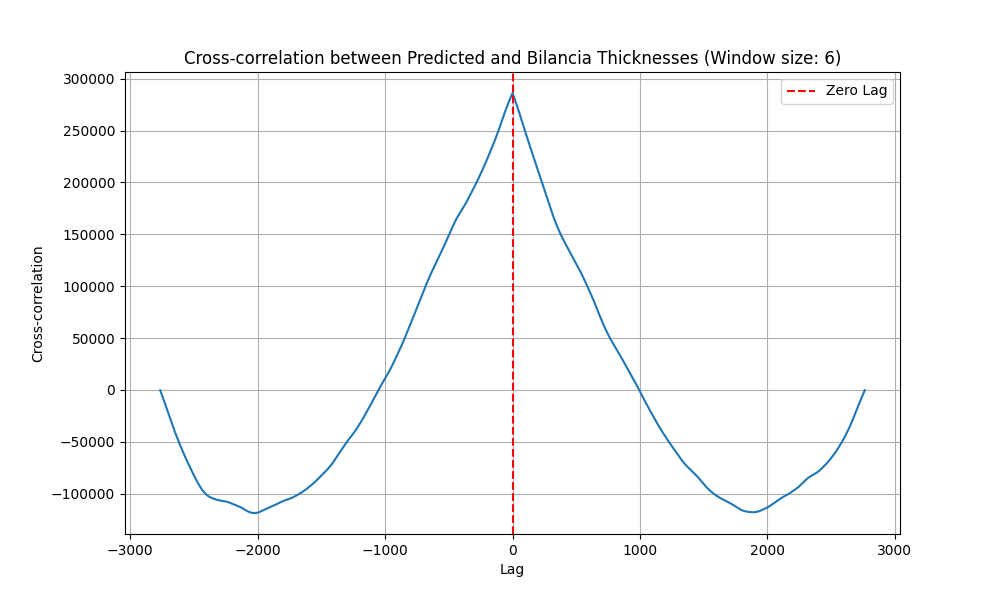

In [47]:
correlation = signal.correlate(predicted_camera_thicknesses_smooth - np.mean(predicted_camera_thicknesses_smooth), bilancia_thicknesses_masked - np.mean(bilancia_thicknesses_masked), mode='full')
lags = signal.correlation_lags(len(predicted_camera_thicknesses_smooth), len(bilancia_thicknesses_masked), mode='full')

plt.figure(figsize=(10,6))
plt.plot(lags, correlation)
plt.xlabel('Lag')
plt.ylabel('Cross-correlation')
plt.title(f'Cross-correlation between Predicted and Bilancia Thicknesses (Window size: {window_size})')
plt.axvline(0, color='red', linestyle='--', label='Zero Lag')
plt.legend()
plt.grid()
plt.show()

Il picco massimo è in corrispondenza di lag=0. Non c'è un ritardo sistematico importante (es. di secondi o minuti) dovuto all'interpolazione o a orologi disallineati. Se ci fosse stato un ritardo fisso, il picco più alto si sarebbe trovato spostato a destra o a sinistra dello zero.

Controllo se anche nei dati di intensità sono presenti delle oscillazioni

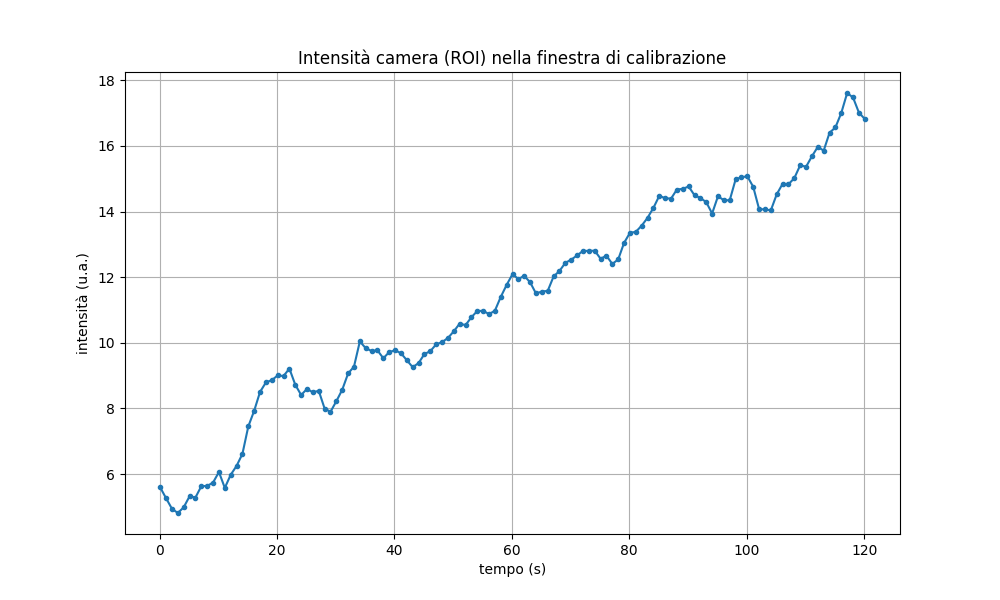

In [48]:
plt.figure(figsize=(10,6))
plt.plot(image_trel, mean_intensities_masked, marker='o', markersize=3)
plt.title("Intensità camera (ROI) nella finestra di calibrazione")
plt.xlabel("tempo (s)")
plt.ylabel("intensità (u.a.)")
plt.grid()
plt.show()

Dati 'calibrazione': l'intensità appare liscia e monotona senza oscillazioni visibili a occhio dal plot dei residui: l'oscillazione nei residui potrebbe emergere dal confronto con la bilancia (es. un problema nell'interpolazione, nel campionamento, o nella bilancia stessa) piuttosto che dal processo di acquisizione dati della camera.  
La curva sembra comunque avere una struttura a gradini...investighiamo

### Verifichiamo se il periodo di questi "gradini" è approssimativamente costante nel tempo o se si accorcia/allunga.

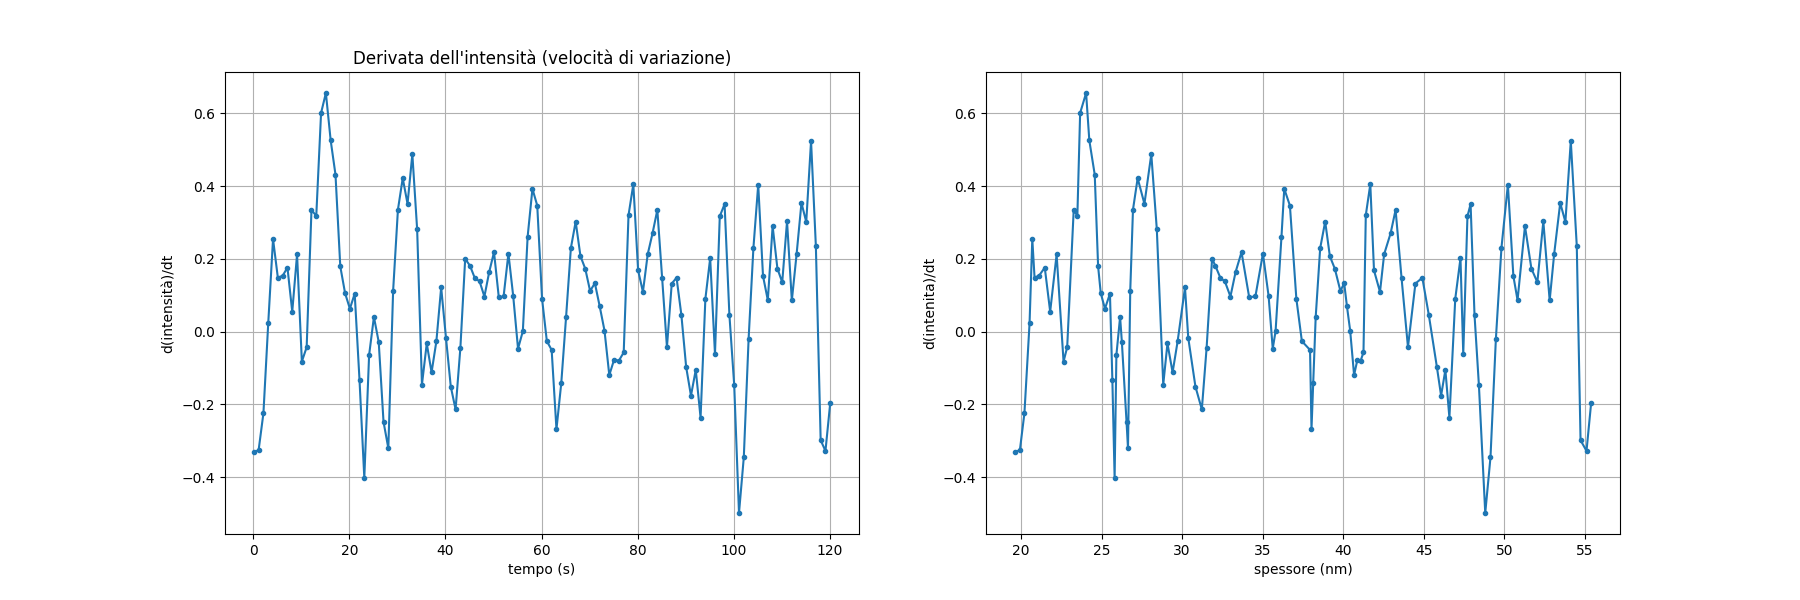

In [49]:
# stimiamo la posizione dei plateau/ripidezza calcolando la derivata numerica
d_intensity = np.gradient(mean_intensities_masked, image_trel)

# spessore della bilancia interpolato sugli stessi istanti della camera (image_trel)
thickness_at_image_times = np.interp(image_trel, bilancia_trel, bilancia_thicknesses_masked)

fig2, (ax4,ax5) = plt.subplots(1,2,figsize=(18,6))

ax4.plot(image_trel, d_intensity, marker='o', markersize=3)
ax4.set_title("Derivata dell'intensità (velocità di variazione)")
ax4.set_xlabel("tempo (s)")
ax4.set_ylabel("d(intensità)/dt")
ax4.grid()

ax5.plot(thickness_at_image_times, d_intensity,marker='o', markersize=3)
ax5.set_xlabel("spessore (nm)")
ax5.set_ylabel("d(intenita)/dt")
ax5.grid()
plt.show()

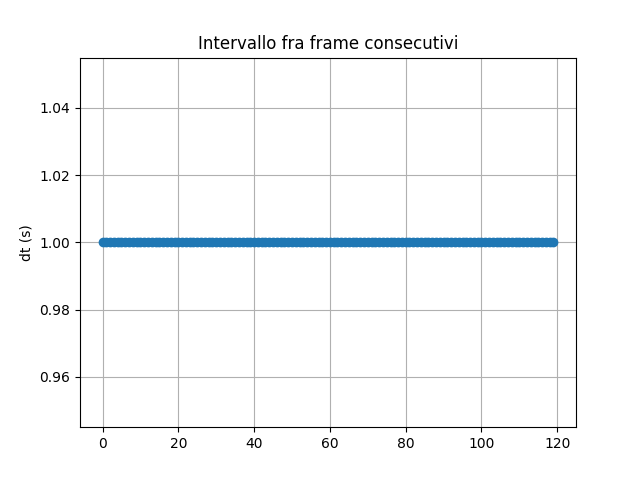

In [50]:
dt = np.diff(image_trel)
#print(dt)
plt.figure()
plt.plot(dt, marker='o')
plt.title("Intervallo fra frame consecutivi")
plt.ylabel("dt (s)")
plt.grid()
plt.show()

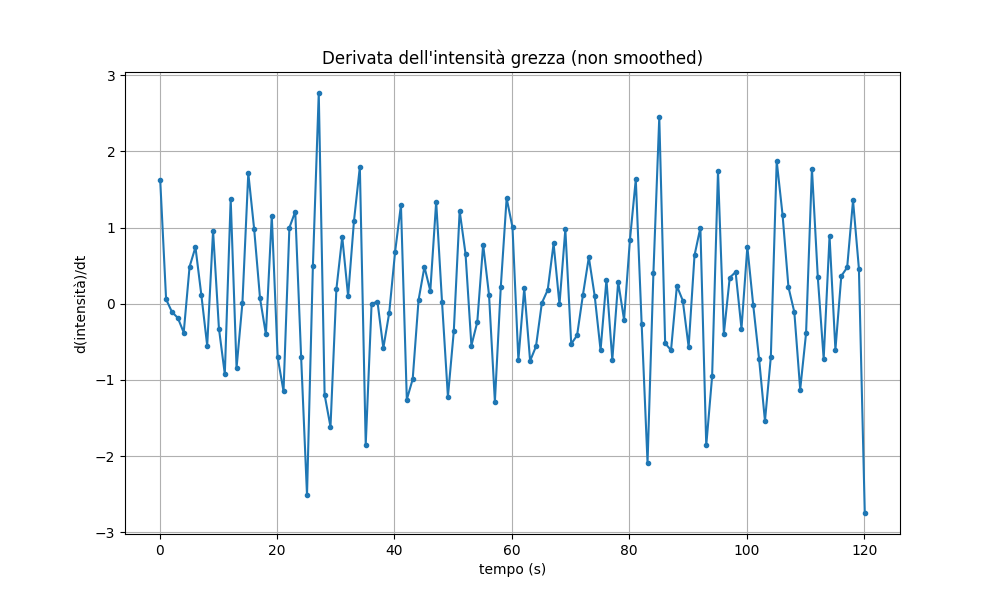

In [51]:
mean_intensities_masked_raw = mean_intensities[image_time_mask]
d_intensity_raw = np.gradient(mean_intensities_masked_raw, image_trel)

plt.figure(figsize=(10,6))
plt.plot(image_trel, d_intensity_raw, marker='o', markersize=3)
plt.title("Derivata dell'intensità grezza (non smoothed)")
plt.xlabel("tempo (s)")
plt.ylabel("d(intensità)/dt")
plt.grid()
plt.show()

Il dato grezzo di intensità è dominato da rumore bianco frame-to-frame

/tmp/ipykernel_26463/4078137711.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6,6))


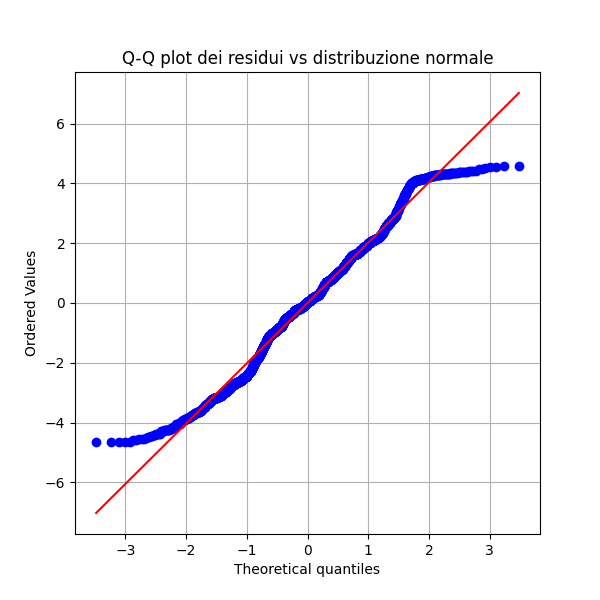

Shapiro-Wilk: statistica=0.9874, p-value=0.000000


In [52]:
from scipy import stats

# Q-Q plot: se i punti seguono la diagonale, la distribuzione è gaussiana
fig, ax = plt.subplots(figsize=(6,6))
stats.probplot(residui_smooth, dist="norm", plot=ax)
ax.set_title("Q-Q plot dei residui vs distribuzione normale")
plt.grid()
plt.show()

# test statistico di normalità
stat, p_value = stats.shapiro(residui_smooth)  # buono per campioni non troppo grandi
print(f"Shapiro-Wilk: statistica={stat:.4f}, p-value={p_value:.6f}")
# p-value basso (<0.05) => rigetto l'ipotesi di normalità

In [53]:
print(bilancia_trel.shape)
print(residui_smooth.shape)

(2766,)
(2766,)


In [54]:
outlier_idx = np.where(np.abs(residui_smooth) > 4*np.std(residui_smooth))[0]
print("Istanti con residuo anomalo:", bilancia_trel[outlier_idx] if len(bilancia_trel)==len(residui_smooth) else "verifica allineamento indici")

Istanti con residuo anomalo: []


In [55]:
"""# identifica l'indice del frame camera corrispondente a questo istante anomalo (solo per 'calibrazione' !!!!)
anomaly_time_range = (image_trel > 31) & (image_trel < 33)
anomaly_idx = np.where(anomaly_time_range)[0]
print("Indici frame camera anomali:", anomaly_idx)
print("Valori di intensità in quei frame:", mean_intensities[anomaly_idx])"""

'# identifica l\'indice del frame camera corrispondente a questo istante anomalo (solo per \'calibrazione\' !!!!)\nanomaly_time_range = (image_trel > 31) & (image_trel < 33)\nanomaly_idx = np.where(anomaly_time_range)[0]\nprint("Indici frame camera anomali:", anomaly_idx)\nprint("Valori di intensità in quei frame:", mean_intensities[anomaly_idx])'

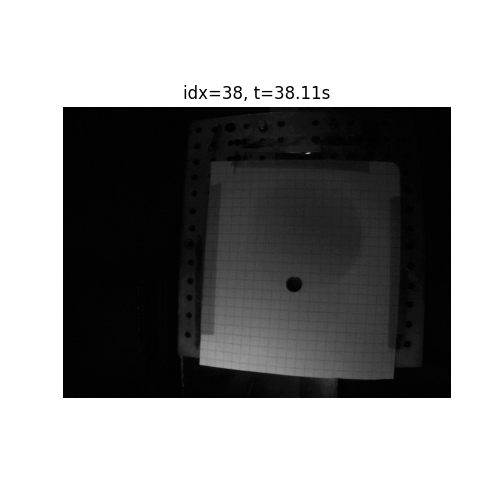

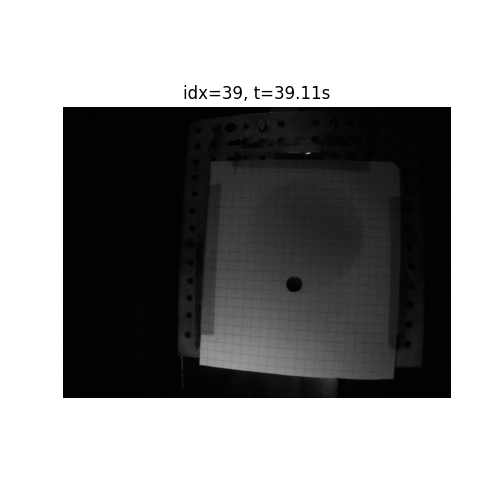

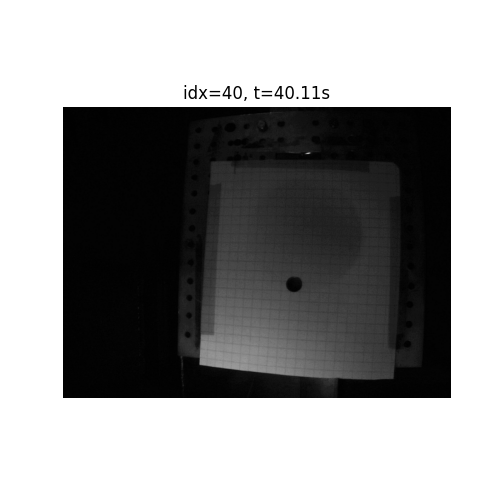

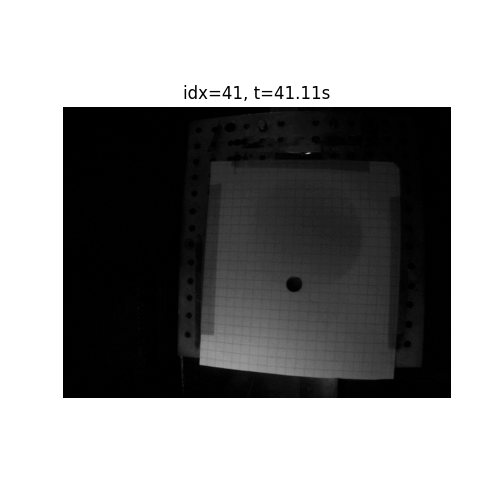

In [56]:
for offset in [-1, 0, 1, 2]:
    idx = anomaly_idx[0] + offset
    plt.figure(figsize=(5,5))
    plt.imshow(images[idx], cmap='gray')
    plt.title(f"idx={idx}, t={image_trel[idx]:.2f}s")
    plt.axis('off')
    plt.show()

In [57]:
print("time passed", bilancia_timestamps[-1] - bilancia_timestamps[0])
print("bilancia_thicknesses", bilancia_thicknesses[-1] - bilancia_thicknesses[0])
print("average rate", (bilancia_thicknesses[-1] - bilancia_thicknesses[0]) / (bilancia_timestamps[-1] - bilancia_timestamps[0]))

time passed 195.9280548095703
bilancia_thicknesses 51.359
average rate 0.2621319343466034


In [58]:
"""avg_rate = (4.5- 0) / (17*60)
avg_rate_min = avg_rate * 60

print(f"Average deposition rate: {avg_rate:.4f} nm/s")
print(f"Average deposition rate: {avg_rate_min:.4f} nm/min")"""

'avg_rate = (4.5- 0) / (17*60)\navg_rate_min = avg_rate * 60\n\nprint(f"Average deposition rate: {avg_rate:.4f} nm/s")\nprint(f"Average deposition rate: {avg_rate_min:.4f} nm/min")'

## Calcolo degli spessori su tutti i dati temporali delle immagini con i dati del fit lineare

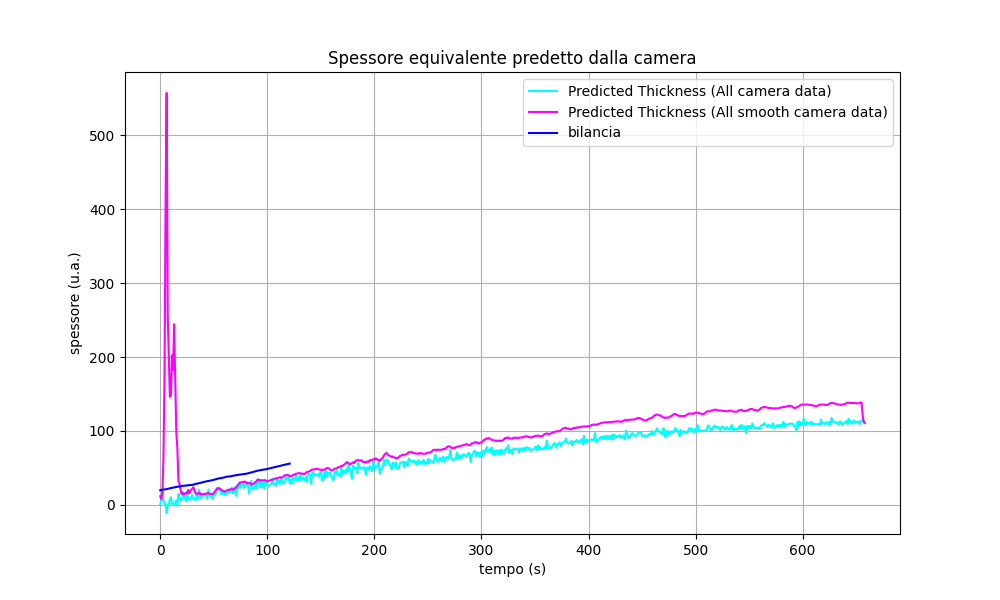

In [89]:
thicknesses_from_smooth_camera_data = m * mean_intensities_smooth + q # questi sono gli spessori predetti dalla camera
thicknesses_from_camera_data = m * mean_intensities + q

plt.figure(figsize=(10, 6))

plt.plot((image_seconds - image_seconds[0]), thicknesses_from_camera_data, label='Predicted Thickness (All camera data)', color='cyan')
plt.plot((image_seconds - image_seconds[0]), thicknesses_from_smooth_camera_data, label='Predicted Thickness (All smooth camera data)', color='magenta')
#plt.plot(image_trel, thicknesses_from_smooth_camera_data)
plt.plot(bilancia_trel, bilancia_thicknesses_masked, label='bilancia', color="blue")
plt.title("Spessore equivalente predetto dalla camera")
plt.xlabel("tempo (s)")
plt.ylabel("spessore (u.a.)")
plt.legend()
plt.grid()
plt.show()

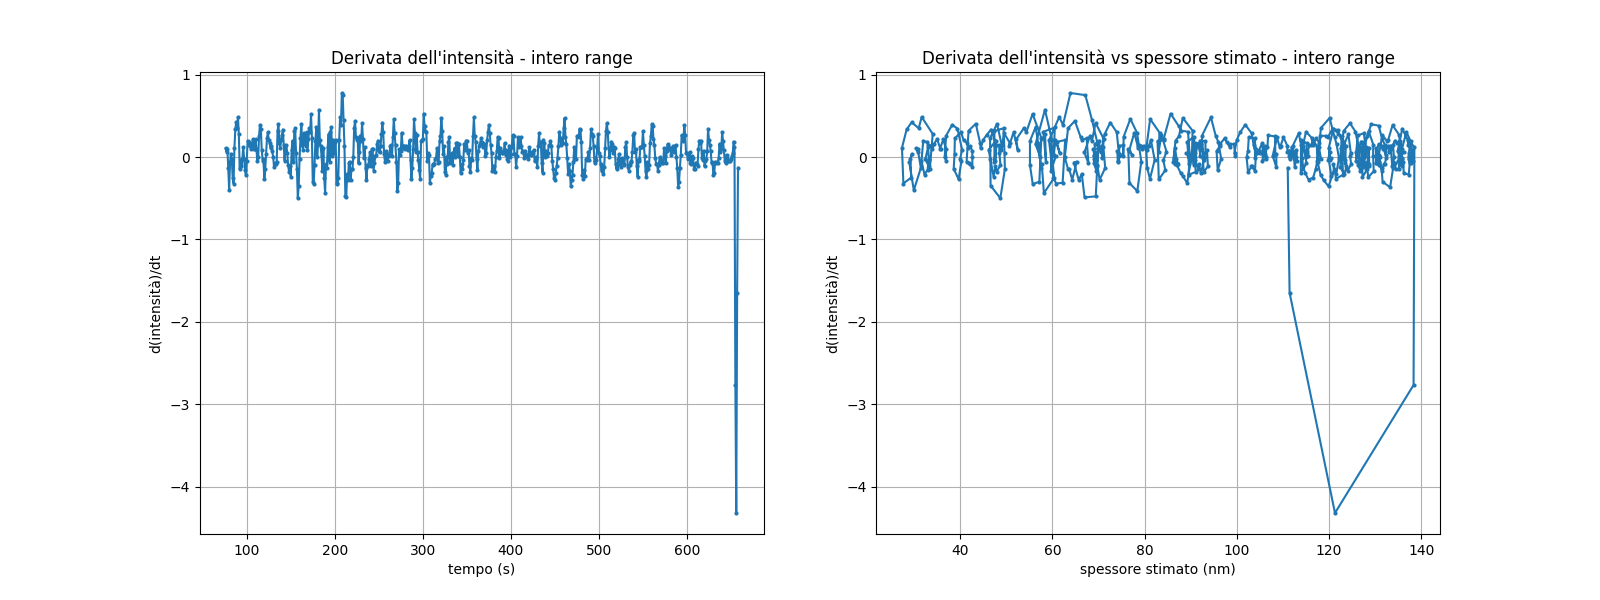

In [60]:
# 1. Calcoliamo la derivata dell'intensità smoothed su TUTTO il range della camera
#    (non solo la finestra di calibrazione a 86s)


image_trel_full = image_seconds - image_seconds[0]
d_intensity_full = np.gradient(mean_intensities_smooth, image_trel_full)

#valid_range = (image_trel_full > 75) #& (image_trel_full < 1060) #per '29-04-2026'
valid_range = (image_trel_full > 75) & (image_trel_full < 1060) #per calibrazione

image_trel_valid = image_trel_full[valid_range]
d_intensity_valid = d_intensity_full[valid_range]
estimated_thickness_valid = thicknesses_from_smooth_camera_data[valid_range]

# 3. Plottiamo entrambi: derivata vs tempo, e derivata vs spessore stimato
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

ax1.plot(image_trel_valid, d_intensity_valid, marker='o', markersize=2)
ax1.set_title("Derivata dell'intensità - intero range")
ax1.set_xlabel("tempo (s)")
ax1.set_ylabel("d(intensità)/dt")
ax1.grid()

ax2.plot(estimated_thickness_valid, d_intensity_valid, marker='o', markersize=2)
ax2.set_title("Derivata dell'intensità vs spessore stimato - intero range")
ax2.set_xlabel("spessore stimato (nm)")
ax2.set_ylabel("d(intensità)/dt")
ax2.grid()

plt.show()

In [61]:
from scipy.signal import periodogram

# scegli due sotto-finestre con tasso di crescita diverso
# (guarda il grafico "Intensità delle immagini" per identificare zone più/meno ripide)

# --- per '29-04-2026'
window_A = (image_trel_full > 100) & (image_trel_full < 200)   # es. zona più ripida
window_B = (image_trel_full > 500) & (image_trel_full < 600)   # es. zona più piatta 

# --- per 'calibrazione'
#window_A = (image_trel_full > 150) & (image_trel_full < 400)   
#window_B = (image_trel_full > 550) & (image_trel_full < 750)


for label, wmask in [('A', window_A), ('B', window_B)]:
    signal_segment = mean_intensities_smooth[wmask]
    t_segment = image_trel_full[wmask]
    dt = np.mean(np.diff(t_segment))
    fs = 1/dt
    
    detrended = signal_segment - np.polyval(np.polyfit(t_segment, signal_segment, 1), t_segment)
    
    freqs, power = periodogram(detrended, fs)
    
    # restringiamo la ricerca alla banda di periodi fra 4 e 15 secondi
    period = np.divide(1, freqs, out=np.full_like(freqs, np.inf), where=freqs>0)
    band_mask = (period >= 4) & (period <= 15)
    
    peak_idx_in_band = np.argmax(power[band_mask])
    peak_freq = freqs[band_mask][peak_idx_in_band]
    
    rate = np.polyfit(t_segment, signal_segment, 1)[0]
    
    print(f"Finestra {label}: periodo dominante (banda 4-15s) = {1/peak_freq:.2f}s, tasso crescita = {rate:.5f} u.a./s")

Finestra A: periodo dominante (banda 4-15s) = 14.14s, tasso crescita = 0.09085 u.a./s
Finestra B: periodo dominante (banda 4-15s) = 11.00s, tasso crescita = 0.02962 u.a./s


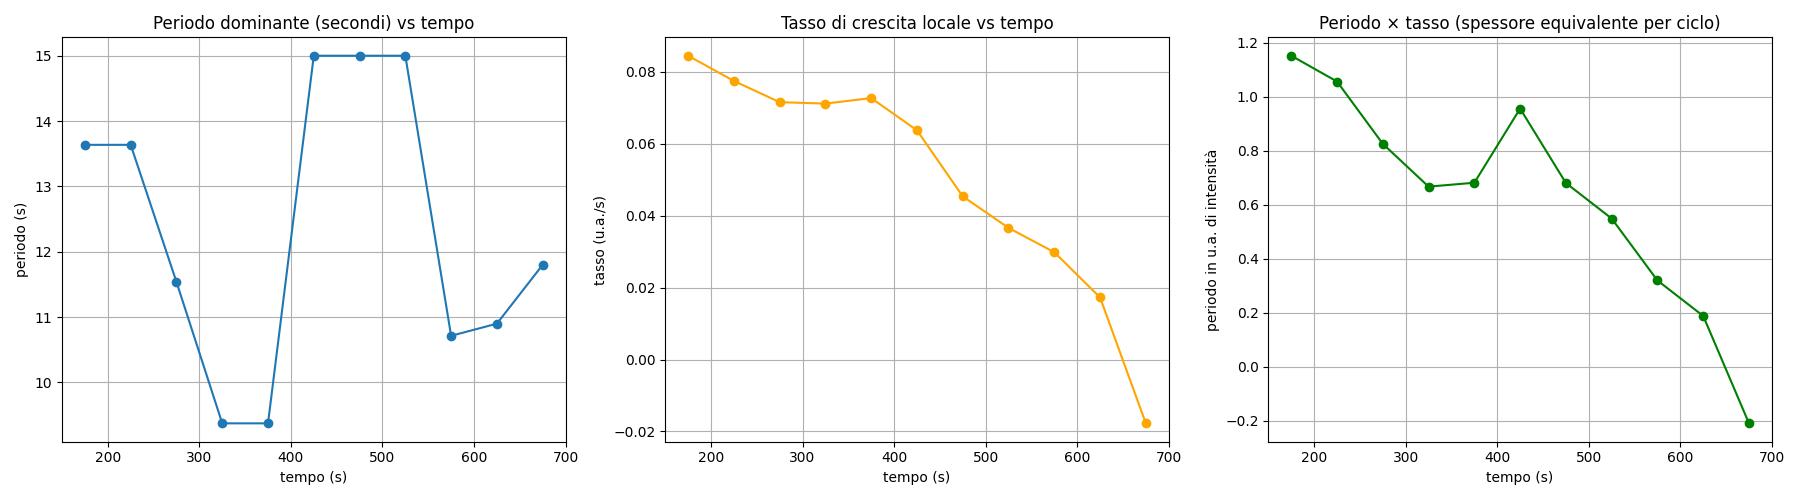

Media periodo×tasso: 0.6241
Deviazione standard: 0.3822
Coefficiente di variazione: 61.2%


In [62]:
window_length = 150   # lunghezza di ogni finestra in secondi
step = 50             # avanzamento fra una finestra e la successiva (finestre sovrapposte)

t_start = 100
t_end = 1060

results = []

t0_w = t_start
while t0_w + window_length <= t_end:
    wmask = (image_trel_full >= t0_w) & (image_trel_full < t0_w + window_length)
    
    t_segment = image_trel_full[wmask]
    signal_segment = mean_intensities_smooth[wmask]
    
    if len(t_segment) < 20:  # scarta finestre con troppo pochi punti
        t0_w += step
        continue
    
    dt = np.mean(np.diff(t_segment))
    fs = 1/dt
    
    # detrend lineare
    fit_coefs = np.polyfit(t_segment, signal_segment, 1)
    rate = fit_coefs[0]
    detrended = signal_segment - np.polyval(fit_coefs, t_segment)
    
    freqs, power = periodogram(detrended, fs)
    period = np.divide(1, freqs, out=np.full_like(freqs, np.inf), where=freqs>0)
    band_mask = (period >= 4) & (period <= 15)
    
    if not np.any(band_mask):
        t0_w += step
        continue
    
    peak_idx = np.argmax(power[band_mask])
    peak_period = period[band_mask][peak_idx]
    
    results.append({
        't_center': t0_w + window_length/2,
        'period_s': peak_period,
        'rate': rate,
        'period_thickness': peak_period * rate
    })
    
    t0_w += step

# estraiamo gli array per plottare
t_centers = [r['t_center'] for r in results]
periods_s = [r['period_s'] for r in results]
rates = [r['rate'] for r in results]
periods_thickness = [r['period_thickness'] for r in results]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,5))

ax1.plot(t_centers, periods_s, marker='o')
ax1.set_title("Periodo dominante (secondi) vs tempo")
ax1.set_xlabel("tempo (s)")
ax1.set_ylabel("periodo (s)")
ax1.grid()

ax2.plot(t_centers, rates, marker='o', color='orange')
ax2.set_title("Tasso di crescita locale vs tempo")
ax2.set_xlabel("tempo (s)")
ax2.set_ylabel("tasso (u.a./s)")
ax2.grid()

ax3.plot(t_centers, periods_thickness, marker='o', color='green')
ax3.set_title("Periodo × tasso (spessore equivalente per ciclo)")
ax3.set_xlabel("tempo (s)")
ax3.set_ylabel("periodo in u.a. di intensità")
ax3.grid()

plt.tight_layout()
plt.show()

print(f"Media periodo×tasso: {np.mean(periods_thickness):.4f}")
print(f"Deviazione standard: {np.std(periods_thickness):.4f}")
print(f"Coefficiente di variazione: {np.std(periods_thickness)/np.mean(periods_thickness)*100:.1f}%")

### Conclusioni

Il fit lineare probabilmente va bene come modello "di primo ordine" ma non ha senso considerare l'errore a 2sigma come errore statistico perché l'errore attorno alla retta non è rumore gaussiano casuale.  
Per il calcolo dell'errore, faccio riferimento ai percentili:

In [63]:
# invece di "predicted ± 2*sigma" (assume gaussianità)
# usa direttamente i percentili empirici dei residui come intervallo di confidenza
ci_lower = tabella_percentili[0.05]  # 5° percentile
ci_upper = tabella_percentili[0.95]  # 95° percentile

print(f"Intervallo di confidenza al 90% (empirico, non-parametrico): [{ci_lower:.3f}, {ci_upper:.3f}]")

Intervallo di confidenza al 90% (empirico, non-parametrico): [-6.920, 7.470]


Non assumo nessuna forma della distribuzione dei residui, l'incertezza è più ampia/asimmetrica di quanto un ±2σ gaussiano farebbe credere.

In [64]:
X = interpolated_intensities_smooth.reshape(-1,1)
y = bilancia_thicknesses_masked  # o l'equivalente nel tuo notebook

huber = HuberRegressor().fit(X, y)
print(f"Huber - slope: {huber.coef_[0]:.4f}, intercept: {huber.intercept_:.4f}")

theilsen = TheilSenRegressor().fit(X, y)
print(f"Theil-Sen - slope: {theilsen.coef_[0]:.4f}, intercept: {theilsen.intercept_:.4f}")

# confronta con il fit OLS classico che avevi già
print(f"OLS (originale) - slope: {slope:.4f}, intercept: {intercept:.4f}")

Huber - slope: 3.0755, intercept: 1.9169
Theil-Sen - slope: 3.1046, intercept: 1.4869
OLS (originale) - slope: 3.0910, intercept: 1.7772


Se questi coefficienti sono vicini a quelli del fit OLS originale, confermano che la retta che abbiamo già è solida e gli outlier non la stanno distorcendo troppo ci teniamo il fit attuale con più fiducia.  
Se invece sono sensibilmente diversi, la regressione robusta dà una calibrazione più affidabile da usare.